<div style="display: flex; align-items: center;">
    <div style="display: flex; flex-direction: column; align-items: center;">
        <h1 style="text-align: right;">Centro de Investigación en Matemáticas, A.C.</h1>
        <h2 style="text-align: right;">Modelos Generativos Profundos</h2>
        <h2 style="text-align: right;">Jose Miguel Saavedra Aguilar</h2>
        <h3 style="text-align: right;">Project 2. Part 1: MNIST</h3>
    </div>
    <img src="https://www.cimat.mx/~adolfofest/images/LOGOTIPO_SIN_FONDO-02.png" alt="CIMAT Logo" width="200" style="float: left;">
</div>


---

## MNIST
On this notebook, we will implement an LSGM model to generate images from the MNIST dataset.

In [ ]:
# Install required libraries for model summaries and metrics
!pip install torchinfo torchmetrics

In [ ]:
# Import core libraries: PyTorch, torchvision, plotting, and helpers
import math, os, gc, time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torchinfo import summary
from torchmetrics import MeanMetric
from tqdm import tqdm
import numpy as np


In [ ]:
# Select device: prefer GPU, then TPU, else CPU
if torch.cuda.is_available():
    # Use CUDA GPU if available
    device = torch.device("cuda")
elif 'TPU_ACCELERATOR_TYPE' in os.environ or 'COLAB_TPU_1vm' in os.environ:
    # Use TPU if running in a TPU environment (e.g., Colab)
    import torch_xla
    import torch_xla.core.xla_model as xm
    device = xm.xla_device()
else:
    # Fallback to CPU
    device = torch.device("cpu")
print(f"Using device: {device}")


Using device: cuda


In [ ]:
# Prepare dataloaders: one for VAE ([0,1] range), one for SSM ([-1,1] range)
transform_vae = transforms.Compose([
    transforms.ToTensor(),  # Convert images to tensor in [0,1]
])
train_dataset_vae = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform_vae
    # Standard MNIST for VAE
    )
train_loader_vae = DataLoader(train_dataset_vae, batch_size=128, shuffle=True, num_workers=0)

# For SSM: pad, randomly rotate, and scale to [-1,1]
transform_ssm = transforms.Compose([
    transforms.Pad(2),  # Pad to 32x32
    transforms.RandomRotation(10),  # Randomly rotate up to 10 degrees
    transforms.ToTensor(),
    lambda x: x * 2 - 1  # Scale to [-1, 1] for diffusion models
    ])
train_dataset_ssm = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform_ssm
    # Augmented MNIST for SSM
    )
train_loader_ssm = DataLoader(train_dataset_ssm, batch_size=128, shuffle=True, num_workers=0)


100%|██████████| 9.91M/9.91M [00:02<00:00, 3.50MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 341kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.36MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.42MB/s]


First, we will train the conditional VAE on MNIST. It is very simple, and similar to the one we used in the previous assignments.

In [ ]:
# VAE reparameterization trick: sample latent z from N(mu, sigma^2) using the reparameterization trick
def reparameterize(mu, log_var):
    # Compute standard deviation from log-variance
    std = torch.exp(0.5 * log_var)
    # Sample epsilon from standard normal distribution
    eps = torch.randn_like(std)
    # Return reparameterized latent vector z = mu + std * eps
    return mu + eps * std


In [ ]:
# Conditional encoder: concatenates class embedding to input features
class ConditionalEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, z_dim, num_classes=10):
        super().__init__()
        # Embedding layer for class labels
        self.embed = nn.Embedding(num_classes, hidden_dim)
        # First fully connected layer takes input and class embedding
        self.fc1 = nn.Linear(input_dim + hidden_dim, hidden_dim)
        # Output layers for mean and log-variance of latent distribution
        self.fc_mu = nn.Linear(hidden_dim, z_dim)
        self.fc_logvar = nn.Linear(hidden_dim, z_dim)

    def forward(self, x, y):
        # Embed class label and concatenate with input features
        class_emb = self.embed(y)
        h = torch.cat([x, class_emb], dim=1)
        # Pass through hidden layer with ReLU activation
        h = F.relu(self.fc1(h))
        # Output mean and log-variance for latent variable z
        mu = self.fc_mu(h)
        log_var = self.fc_logvar(h)
        return mu, log_var


In [ ]:
# Conditional decoder: reconstructs image from latent z and class embedding
class ConditionalDecoder(nn.Module):
    def __init__(self, z_dim, hidden_dim, output_dim, num_classes=10):
        super().__init__()
        # Embedding layer for class labels
        self.embed = nn.Embedding(num_classes, hidden_dim)
        # First fully connected layer takes latent and class embedding
        self.fc1 = nn.Linear(z_dim + hidden_dim, hidden_dim)
        # Output layer reconstructs the image
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, z, y):
        # Embed class label and concatenate with latent vector
        class_emb = self.embed(y)
        h = torch.cat([z, class_emb], dim=1)
        # Pass through hidden layer with ReLU activation
        h = F.relu(self.fc1(h))
        # Output reconstructed image with sigmoid activation (for [0,1] pixel values)
        return torch.sigmoid(self.fc_out(h))


In [ ]:
# Conditional VAE: combines encoder and decoder for class-conditional generation
class ConditionalVAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, z_dim, num_classes=10):
        super().__init__()
        # Encoder maps input and class to latent mean and log-variance
        self.encoder = ConditionalEncoder(input_dim, hidden_dim, z_dim, num_classes)
        # Decoder reconstructs input from latent and class
        self.decoder = ConditionalDecoder(z_dim, hidden_dim, input_dim, num_classes)

    def forward(self, x, y):
        # Encode input and class to latent mean and log-variance
        mu, log_var = self.encoder(x, y)
        # Sample latent vector using reparameterization trick
        z = reparameterize(mu, log_var)
        # Decode latent and class to reconstruct input
        x_recon = self.decoder(z, y)
        return x_recon, mu, log_var


We train the VAE using the ELBO loss function.

In [ ]:
# VAE loss function: ELBO = reconstruction loss + KL divergence
def vae_loss(x, x_recon, mu, log_var):
    # Reconstruction loss (MSE between input and reconstruction)
    recon_loss = F.mse_loss(x_recon, x, reduction="sum")
    # KL divergence between approximate posterior and prior
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + kl_loss


In [ ]:
# Hyperparameters for VAE and latent space
input_dim = 28 * 28        # Flattened MNIST image size
hidden_dim = 512           # Hidden layer size for encoder/decoder
z_dim = 32                 # Latent dimension for VAE
epochs_vae = 100           # Number of VAE training epochs
lr_vae = 1e-3              # Learning rate for VAE optimizer

In [ ]:
# Initialize and prepare VAE training
print("=== Stage 1: Training Conditional VAE ===")
vae = ConditionalVAE(input_dim, hidden_dim, z_dim, num_classes=10).to(device)
vae_optimizer = torch.optim.Adam(vae.parameters(), lr=lr_vae)

=== Stage 1: Training Conditional VAE ===


ConditionalVAE(
  (encoder): ConditionalEncoder(
    (embed): Embedding(10, 512)
    (fc1): Linear(in_features=1296, out_features=512, bias=True)
    (fc_mu): Linear(in_features=512, out_features=32, bias=True)
    (fc_logvar): Linear(in_features=512, out_features=32, bias=True)
  )
  (decoder): ConditionalDecoder(
    (embed): Embedding(10, 512)
    (fc1): Linear(in_features=544, out_features=512, bias=True)
    (fc_out): Linear(in_features=512, out_features=784, bias=True)
  )
)

In [ ]:
# Set VAE to training mode
vae.train()

# VAE training loop: optimize ELBO for each batch
for epoch in range(epochs_vae):
    total_loss = 0.0
    for batch_idx, (x, y) in enumerate(train_loader_vae):
        # Flatten images and move to device
        x = x.view(x.size(0), -1).to(device)
        y = y.to(device)
        vae_optimizer.zero_grad()
        # Forward pass through VAE
        x_recon, mu, log_var = vae(x, y)
        # Compute ELBO loss (reconstruction + KL)
        loss = vae_loss(x, x_recon, mu, log_var)
        loss.backward()
        vae_optimizer.step()
        total_loss += loss.item()
    # Compute average loss per sample for reporting
    avg_loss = total_loss / len(train_loader_vae.dataset)
    print(f"VAE Epoch {epoch+1}/{epochs_vae} | Avg ELBO per sample: {avg_loss:.4f}")


VAE Epoch 1/100 | Avg ELBO per sample: 42.4411
VAE Epoch 2/100 | Avg ELBO per sample: 35.4724
VAE Epoch 3/100 | Avg ELBO per sample: 32.8778
VAE Epoch 4/100 | Avg ELBO per sample: 31.2691
VAE Epoch 5/100 | Avg ELBO per sample: 30.2068
VAE Epoch 6/100 | Avg ELBO per sample: 29.5059
VAE Epoch 7/100 | Avg ELBO per sample: 28.9218
VAE Epoch 8/100 | Avg ELBO per sample: 28.3894
VAE Epoch 9/100 | Avg ELBO per sample: 28.0277
VAE Epoch 10/100 | Avg ELBO per sample: 27.7544
VAE Epoch 11/100 | Avg ELBO per sample: 27.4866
VAE Epoch 12/100 | Avg ELBO per sample: 27.2883
VAE Epoch 13/100 | Avg ELBO per sample: 27.1505
VAE Epoch 14/100 | Avg ELBO per sample: 26.9841
VAE Epoch 15/100 | Avg ELBO per sample: 26.8456
VAE Epoch 16/100 | Avg ELBO per sample: 26.7289
VAE Epoch 17/100 | Avg ELBO per sample: 26.6273
VAE Epoch 18/100 | Avg ELBO per sample: 26.5313
VAE Epoch 19/100 | Avg ELBO per sample: 26.4098
VAE Epoch 20/100 | Avg ELBO per sample: 26.3307
VAE Epoch 21/100 | Avg ELBO per sample: 26.2687
V

In [ ]:
# Save trained VAE weights for reuse
torch.save(vae.state_dict(), "vae_mnist.pth")
print("VAE trained and saved.")


VAE trained and saved.


In [ ]:
# Load VAE weights from file if available, otherwise train from scratch
vae = ConditionalVAE(input_dim, hidden_dim, z_dim, num_classes=10).to(device)
try:
    # Attempt to load pre-trained VAE weights
    state = torch.load("vae_mnist.pth", map_location=device)
    vae.load_state_dict(state)
    print("VAE loaded from file.")
except Exception as e:
    # If loading fails, notify and proceed to train VAE from scratch
    print("Error loading VAE from file:", e)
    print("Train VAE from scratch.")

VAE loaded from file.


We will use the U-Net architecture provided in class for the score network. It has slight modifications to implement class conditioning.

In [ ]:
# DDPM/DDIM utilities for latent diffusion: beta schedule and helpers
def make_beta_schedule(T, beta_start=1e-4, beta_end=0.02):
    # Create a linear schedule for beta (noise variance) from beta_start to beta_end
    return torch.linspace(beta_start, beta_end, T)

# Set up diffusion process parameters for T time steps
T = 1000
betas = make_beta_schedule(T).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - alphas_cumprod)

def extract(a, t, x_shape):
    # Extract values from a buffer at indices t and reshape for broadcasting to x_shape
    b = t.shape[0]
    out = a.gather(-1, t).float()
    return out.reshape(b, *((1,) * (len(x_shape) - 1)))


In [ ]:
# Forward diffusion sampler for q(x_t|x_0) in DDPM
def get_from_idx(element: torch.Tensor, idx: torch.Tensor):
    # Gather values from a buffer at specific indices and reshape for broadcasting
    ele = element.gather(-1, idx)
    return ele.reshape(-1, 1, 1, 1)

# Module for the forward diffusion process (adds noise to data)
class ForwardSampler(nn.Module):
    def __init__(self, timesteps=1000, beta_start=1e-4, beta_end=2e-2):
        super().__init__()
        self.timesteps = timesteps
        # Create a linear schedule for beta (noise variance)
        beta = torch.linspace(
                beta_start,
                beta_end,
                self.timesteps,
                dtype=torch.float32
            )
        # Register buffers for all required diffusion parameters
        self.register_buffer("beta", beta)
        self.register_buffer("alpha", 1 - self.beta)
        self.register_buffer("alpha_bar", torch.cumprod(self.alpha, dim=0))
        self.register_buffer("sqrt_alpha_bar", torch.sqrt(self.alpha_bar))
        self.register_buffer("one_by_sqrt_alpha", 1. / torch.sqrt(self.alpha))
        self.register_buffer("sqrt_one_minus_alpha_bar", torch.sqrt(1 - self.alpha_bar))

    def forward(self, x0: torch.Tensor, timesteps: torch.Tensor):
        # Sample noise to add to the input
        epsilon = torch.randn_like(x0)
        # Compute mean and std for the noisy sample at each time step
        mean    = get_from_idx(self.sqrt_alpha_bar, timesteps) * x0
        std_dev = get_from_idx(self.sqrt_one_minus_alpha_bar, timesteps)
        # Generate the noisy sample
        sample  = mean + std_dev * epsilon
        return sample, epsilon


In [ ]:
# DDPM: implements one backward step in the reverse diffusion process
class DDPM(ForwardSampler):
    def step_backward(self, predicted_noise: torch.Tensor, xnoise: torch.Tensor, timestep: int):
        # Sample random noise for stochasticity, except for the final step
        z = torch.randn_like(xnoise) if timestep > 0 else torch.zeros_like(xnoise)
        # Gather parameters for the current time step and reshape for broadcasting
        beta_t = self.beta[timestep].reshape(-1, 1, 1, 1)
        one_by_sqrt_alpha_t = self.one_by_sqrt_alpha[timestep].reshape(-1, 1, 1, 1)
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alpha_bar[timestep].reshape(-1, 1, 1, 1)
        # Compute the denoised sample for the previous time step
        xdenoised = (
            one_by_sqrt_alpha_t
            * (xnoise - (beta_t / sqrt_one_minus_alpha_bar_t) * predicted_noise)
            + torch.sqrt(beta_t) * z
        )
        return xdenoised


In [ ]:
# Single training step for a diffusion batch
def train_step(batch: torch.Tensor, model: nn.Module, forwardsampler: DDPM):
    # Sample a random time step for each sample in the batch
    t = torch.randint(low=0, high=forwardsampler.timesteps, size=(batch.shape[0],), device=batch.device)
    # Add noise to the batch at time t (forward diffusion)
    x_noisy, eps_true = forwardsampler(batch, t)
    # Predict the noise using the model (score network) with mixed precision
    with torch.amp.autocast('cuda'):
        eps_predicted = model(x_noisy, t)
        # Compute mean squared error loss between predicted and true noise
        loss = F.mse_loss(eps_predicted, eps_true)
    return loss


In [ ]:
# Inference: generate samples by reversing the diffusion process
@torch.inference_mode()
def generate(denoiser_model: nn.Module, backward_sampler: DDPM, size, device):
    # Start from pure Gaussian noise in the latent space
    x_T = torch.randn(size, device=device)
    # Reverse diffusion: iteratively denoise from T to 0
    for t in tqdm(iterable=reversed(range(0, backward_sampler.timesteps)),
                  dynamic_ncols=False, total=backward_sampler.timesteps,
                  desc="Sampling :: ", position=0):
        # Prepare time step tensor for the batch
        t_tensor = torch.as_tensor(t, dtype=torch.long, device=device).reshape(-1).expand(x_T.shape[0])
        # Predict noise for current step
        eps_pred = denoiser_model(x_T, t_tensor)
        # Take one step backward in the diffusion process
        x_T = backward_sampler.step_backward(eps_pred, x_T, t)
    return x_T


In [ ]:
# Sinusoidal time embedding for diffusion models (as in DDPM/Transformer)
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        
    def forward(self, t):
        # Compute sinusoidal embeddings for each time step t
        half = self.dim // 2
        # Exponential decay of frequencies for embedding
        freqs = torch.exp(
            -torch.arange(half, device=t.device) * (math.log(10000) / (half - 1))
        )
        # Outer product: shape [batch, half]
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        # Concatenate sine and cosine embeddings
        return torch.cat([args.sin(), args.cos()], dim=1)


In [ ]:
# Sinusoidal position embedding with MLP expansion for time conditioning
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, total_time_steps=1000, time_emb_dims=128, time_emb_dims_exp=512):
        super().__init__()
        self.total_time_steps = total_time_steps
        self.time_emb_dims = time_emb_dims
        self.time_emb_dims_exp = time_emb_dims_exp

        # Precompute sinusoidal embeddings for all time steps
        half_dim = time_emb_dims // 2
        emb = math.log(10000) / (half_dim - 1 + 1e-8)
        freqs = torch.exp(torch.arange(half_dim, dtype=torch.float32) * -emb)
        ts = torch.arange(total_time_steps, dtype=torch.float32).unsqueeze(1)
        emb_table = torch.cat([
            torch.sin(ts * freqs),
            torch.cos(ts * freqs)
        ], dim=-1)

        self.register_buffer("emb_table", emb_table)

        # MLP to expand the embedding dimension and add nonlinearity
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dims, time_emb_dims_exp),
            nn.SiLU(),
            nn.Linear(time_emb_dims_exp, time_emb_dims_exp),
        )

    def forward(self, time):
        # Look up precomputed sinusoidal embedding and pass through MLP
        emb = self.emb_table[time]
        return self.time_mlp(emb)

In [ ]:
# Attention block for UNet: adds self-attention to spatial features
class AttentionBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.channels  = channels
        # Normalize across channels for stability
        self.group_norm= nn.GroupNorm(num_groups=8, num_channels=channels)
        # Multi-head self-attention over flattened spatial positions
        self.mhsa      = nn.MultiheadAttention(embed_dim=self.channels, num_heads=4, batch_first=True)

    def forward(self, x):
        B, _, H, W = x.shape
        # Normalize and flatten spatial dimensions
        h = self.group_norm(x)
        h = h.reshape(B, self.channels, H * W).swapaxes(1, 2)
        # Apply multi-head self-attention
        h, _ = self.mhsa(h, h, h)
        # Restore original shape and add residual connection
        h = h.swapaxes(2, 1).view(B, self.channels, H, W)
        return x + h

In [ ]:
# ResNet block with time embedding and optional attention for UNet
class ResnetBlock(nn.Module):
    def __init__(self, *, in_channels, out_channels, dropout_rate=0.1, time_emb_dims=512, apply_attention=False):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels= out_channels

        self.activation  = nn.SiLU()
        self.normalize_1 = nn.GroupNorm(num_groups=8, num_channels=self.in_channels)
        self.conv_1      = nn.Conv2d(in_channels=self.in_channels, out_channels=self.out_channels, kernel_size=3, stride=1, padding="same")
        self.dense_1    = nn.Linear(in_features=time_emb_dims, out_features=self.out_channels)
        self.normalize_2= nn.GroupNorm(num_groups=8, num_channels=self.out_channels)
        self.dropout    = nn.Dropout2d(p=dropout_rate)
        self.conv_2     = nn.Conv2d(in_channels=self.out_channels, out_channels=self.out_channels, kernel_size=3, stride=1, padding="same")

        # If input and output channels differ, match dimensions with 1x1 conv
        if self.in_channels != self.out_channels:
            self.match_input = nn.Conv2d(in_channels=self.in_channels, out_channels=self.out_channels, kernel_size=1, stride=1)
        else:
            self.match_input = nn.Identity()

        # Optionally add attention block
        if apply_attention:
            self.attention = AttentionBlock(channels=self.out_channels)
        else:
            self.attention = nn.Identity()

    def forward(self, x, t):
        # First normalization, activation, and convolution
        h = self.activation(self.normalize_1(x))
        h = self.conv_1(h)
        # Add time embedding (broadcasted to spatial dims)
        h += self.dense_1(self.activation(t))[:, :, None, None]
        # Second normalization, activation, dropout, and convolution
        h = self.activation(self.normalize_2(h))
        h = self.dropout(h)
        h = self.conv_2(h)
        # Add skip connection (input, possibly projected)
        h = h + self.match_input(x)
        # Optionally apply attention
        h = self.attention(h)
        return h

In [ ]:
# Downsampling and upsampling layers for UNet
class DownSample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        # Downsample by strided convolution (halves spatial size)
        self.downsample = nn.Conv2d(in_channels=channels, out_channels=channels, kernel_size=3, stride=2, padding=1)
    def forward(self, x, *args):
        return self.downsample(x)

class UpSample(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        # Upsample by nearest neighbor, then refine with convolution
        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(in_channels=in_channels, out_channels=in_channels, kernel_size=3, stride=1, padding=1))
    def forward(self, x, *args):
        return self.upsample(x)

In [ ]:
# UNet implementation with class conditioning for latent diffusion
class UNet(nn.Module):
    def __init__(
        self,
        input_channels = 3,
        output_channels= 3,
        num_res_blocks = 2,
        base_channels  = 128,
        # Resolutions
        base_channels_multiples=(1, 2, 4, 8),
        # Attention, per resolution level
        apply_attention=(False, False, True, False),
        dropout_rate=0.1,
        time_multiple=4,
        num_classes=10,
    ):
        super().__init__()

        # Expand time embedding for conditioning
        time_emb_dims_exp = base_channels * time_multiple
        self.time_embeddings = SinusoidalPositionEmbeddings(time_emb_dims=base_channels, time_emb_dims_exp=time_emb_dims_exp)
        self.class_emb = nn.Embedding(num_classes, time_emb_dims_exp)
        self.first = nn.Conv2d(in_channels=input_channels, out_channels=base_channels, kernel_size=3, stride=1, padding="same")

        num_resolutions = len(base_channels_multiples)

        # Encoder: progressively downsample and increase channels
        self.encoder_blocks = nn.ModuleList()
        curr_channels = [base_channels]
        in_channels = base_channels

        for level in range(num_resolutions):
            out_channels = base_channels * base_channels_multiples[level]

            for _ in range(num_res_blocks):
                block = ResnetBlock(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    dropout_rate=dropout_rate,
                    time_emb_dims=time_emb_dims_exp * 2,
                    apply_attention=apply_attention[level],
                )
                self.encoder_blocks.append(block)
                in_channels = out_channels
                curr_channels.append(in_channels)

            # Add downsampling except for last level
            if level != (num_resolutions - 1):
                self.encoder_blocks.append(DownSample(channels=in_channels))
                curr_channels.append(in_channels)

        # Bottleneck: two ResNet blocks, one with attention
        self.bottleneck_blocks = nn.ModuleList((
            ResnetBlock(
                in_channels=in_channels,
                out_channels=in_channels,
                dropout_rate=dropout_rate,
                time_emb_dims=time_emb_dims_exp * 2,
                apply_attention=True,
            ),
            ResnetBlock(
                in_channels=in_channels,
                out_channels=in_channels,
                dropout_rate=dropout_rate,
                time_emb_dims=time_emb_dims_exp * 2,
                apply_attention=False,
            ),
        ))

        # Decoder: upsample and merge with encoder features (skip connections)
        self.decoder_blocks = nn.ModuleList()

        for level in reversed(range(num_resolutions)):
            out_channels = base_channels * base_channels_multiples[level]

            for _ in range(num_res_blocks + 1):
                encoder_in_channels = curr_channels.pop()
                block = ResnetBlock(
                    in_channels=encoder_in_channels + in_channels,
                    out_channels=out_channels,
                    dropout_rate=dropout_rate,
                    time_emb_dims=time_emb_dims_exp * 2,
                    apply_attention=apply_attention[level],
                )

                in_channels = out_channels
                self.decoder_blocks.append(block)

            if level != 0:
                self.decoder_blocks.append(UpSample(in_channels))

        # Final normalization and output convolution
        self.final = nn.Sequential(
            nn.GroupNorm(num_groups=8, num_channels=in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels=in_channels, out_channels=output_channels, kernel_size=3, stride=1, padding="same"),
        )

    def forward(self, x, t, y):
        # x: [B, z_dim, 1, 1], t: [B], y: [B]
        # Compute time and class embeddings for conditioning
        time_emb = self.time_embeddings(t)
        class_emb = self.class_emb(y)
        cond_emb = torch.cat([time_emb, class_emb], dim=1)
        h = self.first(x)
        outs = [h]

        # Encoder: downsample and store intermediate outputs for skip connections
        for layer in self.encoder_blocks:
            h = layer(h, cond_emb)
            outs.append(h)

        # Bottleneck: process with two ResNet blocks
        for layer in self.bottleneck_blocks:
            h = layer(h, cond_emb)

        # Decoder: upsample and concatenate with encoder outputs
        for layer in self.decoder_blocks:
            if isinstance(layer, ResnetBlock):
                out = outs.pop()
                # Ensure spatial dimensions match before concatenation
                if h.shape[2:] != out.shape[2:]:
                    min_h, min_w = min(h.shape[2], out.shape[2]), min(h.shape[3], out.shape[3])
                    h = h[:, :, :min_h, :min_w]
                    out = out[:, :, :min_h, :min_w]
                h = torch.cat([h, out], dim=1)
            h = layer(h, cond_emb)

        # Final normalization and output
        h = self.final(h)

        return h

In [ ]:
# Stage 2: Train the latent DDPM (UNet) score network
print("\n=== Stage 2: Training Latent DDPM Score Model ===")
# Freeze VAE parameters so only the score network is trained
for param in vae.parameters():
    param.requires_grad_(False)
vae.eval()

# Initialize the conditional UNet as the score network for latent diffusion
denoiser_model = UNet(
    input_channels=z_dim,
    output_channels=z_dim,
    base_channels=128,
    base_channels_multiples=(1, 2, 2),        # 3 levels: 16 → 8 → 4
    apply_attention=(False, True, True),      # attention at 8×8 and 4×4
    num_res_blocks=2,
    dropout_rate=0.1,
    time_multiple=4,
    num_classes=10,
    # ...other hyperparameters as needed
).to(device)

# Set up optimizer and learning rate scheduler for the score network
optimizer = torch.optim.AdamW(denoiser_model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# Create the DDPM forward/backward sampler for latent diffusion
diffusionmodel = DDPM(timesteps = 1000)
diffusionmodel.to(device)

# Enable mixed precision training for efficiency
scaler = torch.amp.GradScaler('cuda')

# Number of training epochs for the score network
ddpm_epochs = 50


=== Stage 2: Training Latent DDPM Score Model ===


Note the weights $w_t$ mentioned in the report.

In [ ]:
# Training: one epoch for latent diffusion
def train_one_epoch(model, sampler, loader, optimizer, scaler, vae, device, epoch=1):
    loss_record = MeanMetric().to(device)
    model.train()
    vae.eval()  # VAE is frozen during score network training

    with tqdm(total=len(loader), dynamic_ncols=True) as tq:
        tq.set_description(f"Train :: Epoch: {epoch}")
        for x, y in loader:
            tq.update(1)
            # Flatten images and move to device
            x = x.view(x.size(0), -1).to(device)
            y = y.to(device)

            # Get latent z from VAE encoder (no grad, as VAE is frozen)
            with torch.no_grad():
                mu, log_var = vae.encoder(x, y)
                z = reparameterize(mu, log_var)  # [B, z_dim]
                z = z.unsqueeze(-1).unsqueeze(-1)  # [B, z_dim, 1, 1]

            # Sample random time step for each sample
            t = torch.randint(0, sampler.timesteps, (z.size(0),), device=device)
            # Forward diffusion: add noise to latent z
            z_t, eps_true = sampler(z, t)

            # Predict noise with the score network
            with torch.amp.autocast('cuda'):
                eps_pred = model(z_t, t, y)

                # Compute per-sample mean squared error
                se = (eps_pred - eps_true).pow(2)                     # [B, C, H, W]
                se_per_sample = se.view(se.size(0), -1).mean(dim=1)  # [B]

                # Compute weighting for each time step
                beta_t = sampler.beta[t].to(z.device)
                alpha_bar_t = sampler.alpha_bar[t].to(z.device)
                # Weight as proposed: w_t = beta_t / (1 - alpha_bar_t)
                w_t = beta_t / (1.0 - alpha_bar_t + 1e-12)

                # Final loss: mean over batch of (w_t/2 * mse_per_sample)
                loss = 0.5 * (w_t * se_per_sample).mean()

            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            loss_value = loss.detach().item()
            loss_record.update(loss_value)

            tq.set_postfix_str(s=f"Loss: {loss_value:.4f}")

        mean_loss = loss_record.compute().item()
        tq.set_postfix_str(s=f"Epoch Loss: {mean_loss:.4f}")

    return mean_loss

Once the VAE weights are frozen, we proceed to train the score network.

Train :: Epoch: 10: 100%|██████████| 469/469 [00:40<00:00, 11.46it/s, Epoch Loss: 0.0048]


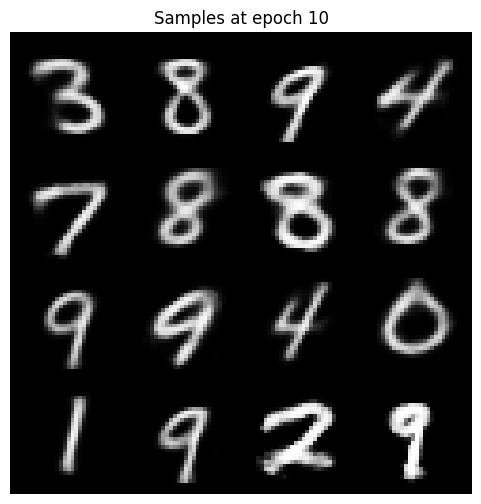

Train :: Epoch: 20: 100%|██████████| 469/469 [00:32<00:00, 14.59it/s, Epoch Loss: 0.0047]


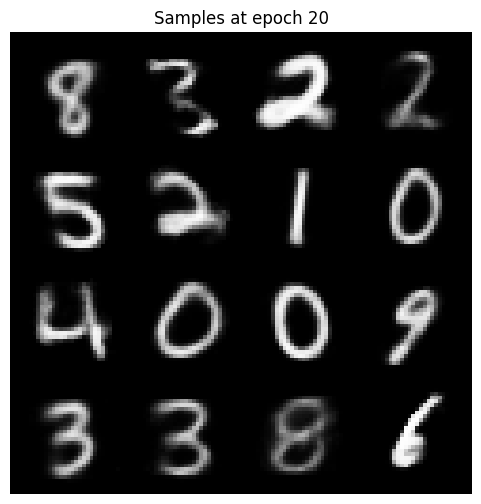

Train :: Epoch: 30: 100%|██████████| 469/469 [00:31<00:00, 14.74it/s, Epoch Loss: 0.0050]


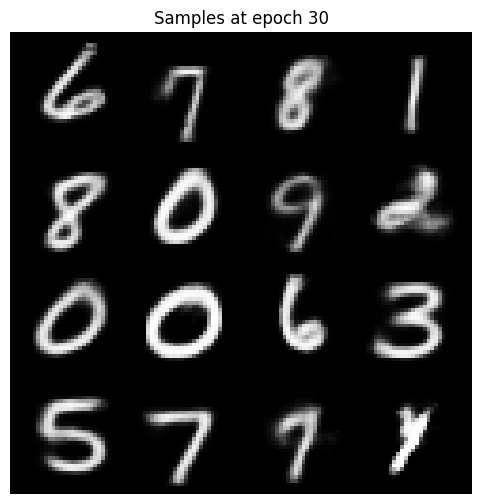

Train :: Epoch: 40: 100%|██████████| 469/469 [00:31<00:00, 14.77it/s, Epoch Loss: 0.0048]


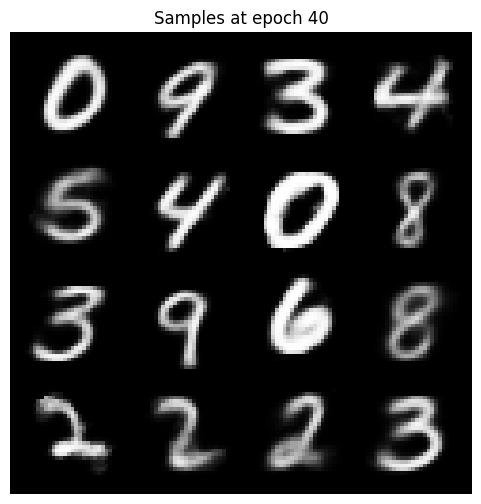

Train :: Epoch: 50: 100%|██████████| 469/469 [00:35<00:00, 13.23it/s, Epoch Loss: 0.0048]


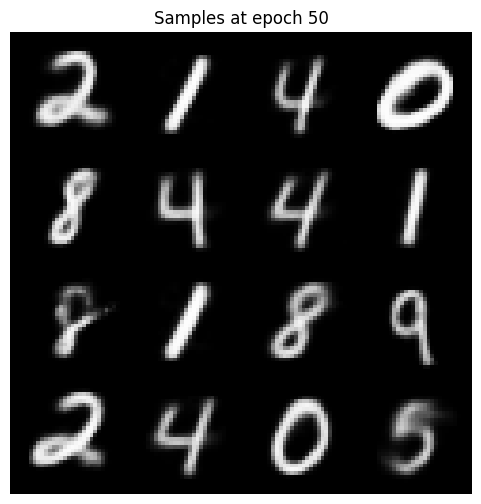

In [ ]:
# Main training loop for latent diffusion; includes periodic sample visualization
for epoch in range(1, ddpm_epochs + 1):
    torch.cuda.empty_cache()
    gc.collect()

    # Train for one epoch
    train_one_epoch(
        denoiser_model, diffusionmodel, train_loader_vae, optimizer, scaler, vae, device, epoch=epoch
)

    # Every 10 epochs, generate and visualize samples from the current model
    if epoch % 10 == 0:
        denoiser_model.eval()
        with torch.no_grad():
            # Generate random class labels and initial latent noise
            y_sample = torch.randint(0, 10, (16,), device=device)
            z_T = torch.randn(16, z_dim, 1, 1, device=device)
            z = z_T
            # Reverse diffusion process to generate latents
            for t in reversed(range(diffusionmodel.timesteps)):
                t_batch = torch.full((16,), t, device=device, dtype=torch.long)
                eps_pred = denoiser_model(z, t_batch, y_sample)
                z = diffusionmodel.step_backward(eps_pred, z, t)
            # Decode latents to images using VAE decoder
            x_gen = vae.decoder(z.squeeze(-1).squeeze(-1), y_sample)
            x_gen = x_gen.view(-1, 1, 28, 28).cpu().clamp(0, 1)
            # Visualize generated samples in a grid
            grid = torchvision.utils.make_grid(x_gen, nrow=4)
            plt.figure(figsize=(6,6)); plt.axis('off'); plt.title(f"Samples at epoch {epoch}")
            plt.imshow(grid.permute(1,2,0).squeeze(), cmap='gray'); plt.show()

In [ ]:
# Save the trained DDPM score network weights for future use
torch.save(denoiser_model.state_dict(), "latent_ddpm_score_net_mnist.pth")
print("Latent DDPM score model trained and saved.")

Latent DDPM score model trained and saved.


Now, we train jointly the score network and the VAE.

100%|██████████| 469/469 [00:42<00:00, 11.15it/s]


Joint Epoch 1/20 | Avg VAE ELBO: 24.5495 | Avg Diff Loss: 0.0000


100%|██████████| 469/469 [00:41<00:00, 11.18it/s]


Joint Epoch 2/20 | Avg VAE ELBO: 24.5204 | Avg Diff Loss: 0.0000


100%|██████████| 469/469 [00:40<00:00, 11.68it/s]


Joint Epoch 3/20 | Avg VAE ELBO: 24.5044 | Avg Diff Loss: 0.0000


100%|██████████| 469/469 [00:40<00:00, 11.69it/s]


Joint Epoch 4/20 | Avg VAE ELBO: 24.4985 | Avg Diff Loss: 0.0000


100%|██████████| 469/469 [00:40<00:00, 11.66it/s]


Joint Epoch 5/20 | Avg VAE ELBO: 24.4704 | Avg Diff Loss: 0.0000


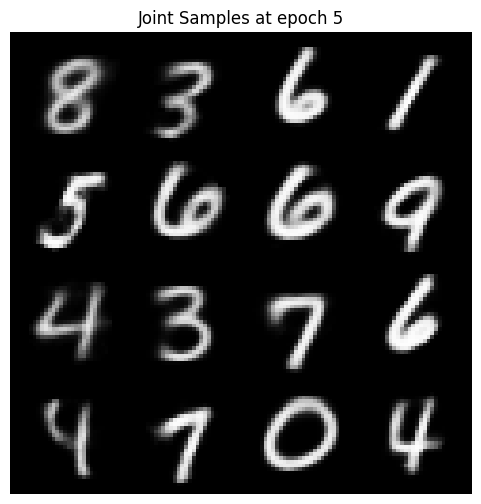

100%|██████████| 469/469 [00:30<00:00, 15.15it/s]


Joint Epoch 6/20 | Avg VAE ELBO: 24.4677 | Avg Diff Loss: 0.0000


100%|██████████| 469/469 [00:31<00:00, 15.06it/s]


Joint Epoch 7/20 | Avg VAE ELBO: 24.4455 | Avg Diff Loss: 0.0000


100%|██████████| 469/469 [00:37<00:00, 12.63it/s]


Joint Epoch 8/20 | Avg VAE ELBO: 24.4646 | Avg Diff Loss: 0.0000


100%|██████████| 469/469 [00:31<00:00, 14.85it/s]


Joint Epoch 9/20 | Avg VAE ELBO: 24.4474 | Avg Diff Loss: 0.0000


100%|██████████| 469/469 [00:30<00:00, 15.15it/s]


Joint Epoch 10/20 | Avg VAE ELBO: 24.4404 | Avg Diff Loss: 0.0000


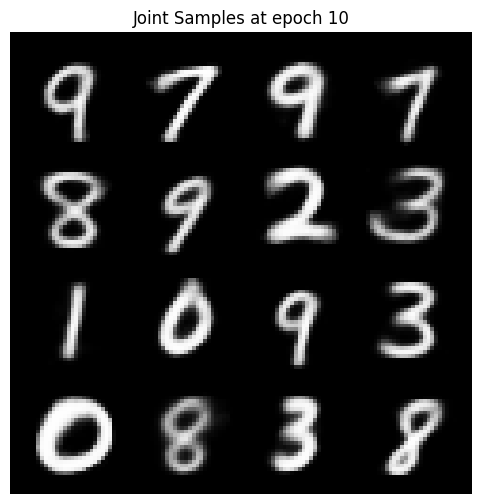

100%|██████████| 469/469 [00:31<00:00, 15.11it/s]


Joint Epoch 11/20 | Avg VAE ELBO: 24.4430 | Avg Diff Loss: 0.0000


100%|██████████| 469/469 [00:30<00:00, 15.21it/s]


Joint Epoch 12/20 | Avg VAE ELBO: 24.4406 | Avg Diff Loss: 0.0000


100%|██████████| 469/469 [00:31<00:00, 14.99it/s]


Joint Epoch 13/20 | Avg VAE ELBO: 24.4381 | Avg Diff Loss: 0.0000


100%|██████████| 469/469 [00:37<00:00, 12.62it/s]


Joint Epoch 14/20 | Avg VAE ELBO: 24.4303 | Avg Diff Loss: 0.0000


100%|██████████| 469/469 [00:41<00:00, 11.23it/s]


Joint Epoch 15/20 | Avg VAE ELBO: 24.4404 | Avg Diff Loss: 0.0000


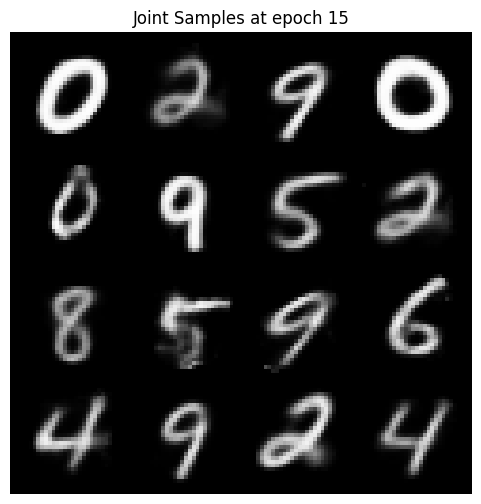

100%|██████████| 469/469 [00:33<00:00, 14.13it/s]


Joint Epoch 16/20 | Avg VAE ELBO: 24.4364 | Avg Diff Loss: 0.0000


100%|██████████| 469/469 [00:29<00:00, 15.64it/s]


Joint Epoch 17/20 | Avg VAE ELBO: 24.4175 | Avg Diff Loss: 0.0000


100%|██████████| 469/469 [00:29<00:00, 15.79it/s]


Joint Epoch 18/20 | Avg VAE ELBO: 24.4309 | Avg Diff Loss: 0.0000


100%|██████████| 469/469 [00:29<00:00, 15.75it/s]


Joint Epoch 19/20 | Avg VAE ELBO: 24.4375 | Avg Diff Loss: 0.0000


100%|██████████| 469/469 [00:29<00:00, 15.79it/s]


Joint Epoch 20/20 | Avg VAE ELBO: 24.4305 | Avg Diff Loss: 0.0000


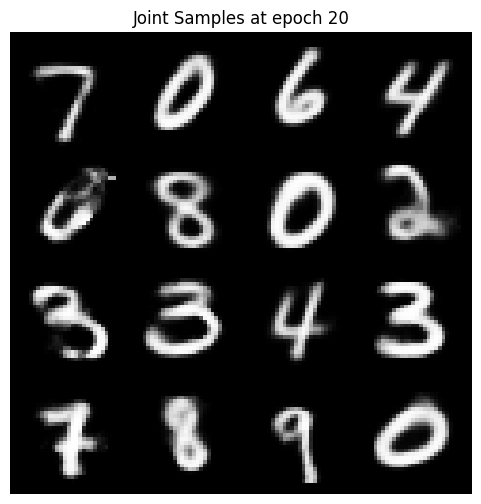

In [ ]:
# Unfreeze VAE and set up joint optimizer for both models
for param in vae.parameters():
    param.requires_grad_(True)

# Create a new optimizer for both VAE and diffusion model parameters
joint_optimizer = torch.optim.AdamW(
    list(vae.parameters()) + list(denoiser_model.parameters()), lr=1e-4
)

joint_epochs = 20  # Number of joint training epochs (adjust as needed)

# Joint training loop: optimize both VAE and score network together
for epoch in range(1, joint_epochs + 1):
    vae.train()
    denoiser_model.train()
    total_vae_loss = 0.0
    total_diff_loss = 0.0
    for x, y in tqdm(train_loader_vae):
        x = x.view(x.size(0), -1).to(device)
        y = y.to(device)

        # Forward pass through VAE
        x_recon, mu, log_var = vae(x, y)
        vae_elbo = vae_loss(x, x_recon, mu, log_var)

        # Get latent z for diffusion
        z = reparameterize(mu, log_var).unsqueeze(-1).unsqueeze(-1)

        # Diffusion loss: add noise to latent and predict it
        t = torch.randint(0, diffusionmodel.timesteps, (z.size(0),), device=device)
        z_t, eps_true = diffusionmodel(z, t)
        with torch.amp.autocast('cuda'):
            eps_pred = denoiser_model(z_t, t, y)
            # Compute per-sample mean squared error
            se = (eps_pred - eps_true).pow(2)                     # [B, C, H, W]
            se_per_sample = se.view(se.size(0), -1).mean(dim=1)  # [B]

            # Compute weighting for each time step
            beta_t = diffusionmodel.beta[t].to(z.device)
            alpha_bar_t = diffusionmodel.alpha_bar[t].to(z.device)
            w_t = beta_t / (1.0 - alpha_bar_t + 1e-12)

            # Final diffusion loss: weighted MSE
            diff_loss = 0.5 * (w_t * se_per_sample).mean()

        # Joint loss: sum of VAE ELBO and diffusion loss
        loss = vae_elbo + diff_loss

        joint_optimizer.zero_grad(set_to_none=True)
        loss.backward()
        joint_optimizer.step()

        total_vae_loss += vae_elbo.item()
        total_diff_loss += diff_loss.item()

    # Compute average losses for reporting
    avg_vae_loss = total_vae_loss / len(train_loader_vae.dataset)
    avg_diff_loss = total_diff_loss / len(train_loader_vae.dataset)
    print(f"Joint Epoch {epoch}/{joint_epochs} | Avg VAE ELBO: {avg_vae_loss:.4f} | Avg Diff Loss: {avg_diff_loss:.4f}")

    # Optionally: sample and visualize as before
    if epoch % 5 == 0:
        denoiser_model.eval()
        vae.eval()
        with torch.no_grad():
            # Generate random class labels and latent noise
            y_sample = torch.randint(0, 10, (16,), device=device)
            z_T = torch.randn(16, z_dim, 1, 1, device=device)
            z = z_T
            # Reverse diffusion process to generate latents
            for t in reversed(range(diffusionmodel.timesteps)):
                t_batch = torch.full((16,), t, device=device, dtype=torch.long)
                eps_pred = denoiser_model(z, t_batch, y_sample)
                z = diffusionmodel.step_backward(eps_pred, z, t)
            # Decode latents to images using VAE decoder
            x_gen = vae.decoder(z.squeeze(-1).squeeze(-1), y_sample)
            x_gen = x_gen.view(-1, 1, 28, 28).cpu().clamp(0, 1)
            # Visualize generated samples in a grid
            grid = torchvision.utils.make_grid(x_gen, nrow=4)
            plt.figure(figsize=(6,6)); plt.axis('off'); plt.title(f"Joint Samples at epoch {epoch}")
            plt.imshow(grid.permute(1,2,0).squeeze(), cmap='gray'); plt.show()

Now, we use DDIM to generate samples from the trained LSGM model.

Sampling :: 100%|██████████| 100/100 [00:01<00:00, 65.53it/s]


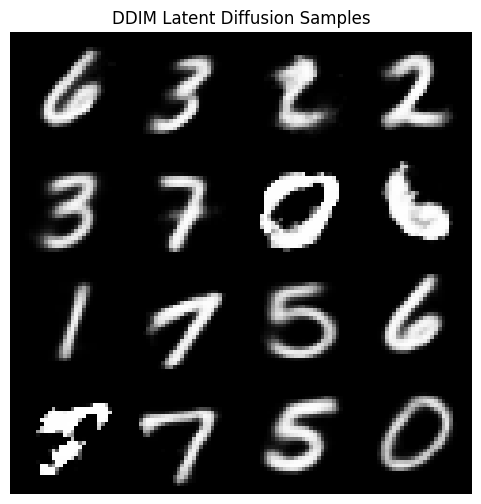

In [ ]:
# DDIM sampling for conditional latent diffusion
@torch.inference_mode()
def generate_ddim(denoiser_model, taus, backward_sampler, size, device, y=None):
    # Start from pure Gaussian noise in the latent space
    xnoisy = torch.randn(size, device=device)
    # Set the model in evaluation mode for inference
    denoiser_model.eval()
    # Initialize time step variables for the last step
    last_t = torch.ones(size[0], dtype=torch.long, device=device) * (backward_sampler.timesteps-1)
    alpha_bar_t = get_from_idx(backward_sampler.alpha_bar, last_t)
    sqrt_alpha_bar_t = get_from_idx(backward_sampler.sqrt_alpha_bar, last_t)
    sqrt_one_minus_alpha_bar_t = get_from_idx(backward_sampler.sqrt_one_minus_alpha_bar, last_t)
    # Reverse the diffusion process using a sequence of denoising steps
    for t in tqdm(iterable=reversed(taus),
                          dynamic_ncols=False,total=len(taus),
                          desc="Sampling :: ", position=0):
        # Prepare time step tensor for the batch
        ts = torch.ones(size[0], dtype=torch.long, device=device) * t
        # If y is not provided, generate random labels for conditional generation
        if y is not None:
            y_cond = y
        else:
            y_cond = torch.randint(0, 10, (size[0],), device=device)
        # Predict noise for the current step
        predicted_noise = denoiser_model(xnoisy, ts, y_cond)
        # Compute parameters for the previous time step
        alpha_bar_t_prev = get_from_idx(backward_sampler.alpha_bar, ts)
        sqrt_alpha_bar_t_prev = get_from_idx(backward_sampler.sqrt_alpha_bar, ts)
        sqrt_one_minus_alpha_bar_t_prev = get_from_idx(backward_sampler.sqrt_one_minus_alpha_bar, ts)
        # Estimate the original latent and update the noisy latent for the next step
        predicted_x0 = (xnoisy - sqrt_one_minus_alpha_bar_t * predicted_noise) / sqrt_alpha_bar_t
        xnoisy = sqrt_alpha_bar_t_prev * predicted_x0 + sqrt_one_minus_alpha_bar_t_prev * predicted_noise
        # Update variables for the next iteration
        alpha_bar_t = alpha_bar_t_prev
        sqrt_alpha_bar_t = sqrt_alpha_bar_t_prev
        sqrt_one_minus_alpha_bar_t = sqrt_one_minus_alpha_bar_t_prev
    return xnoisy

# Example usage for latent diffusion with DDIM sampling
ddim_stepsize = 10  # Number of steps to skip between denoising steps
taus = np.arange(0, diffusionmodel.timesteps, ddim_stepsize)
y_sample = torch.randint(0, 10, (16,), device=device)  # Random class labels for conditional generation
z_latents = generate_ddim(denoiser_model, taus, diffusionmodel, (16, z_dim, 1, 1), device, y=y_sample)
# Decode the generated latents to images using the VAE decoder
x_gen = vae.decoder(z_latents.squeeze(-1).squeeze(-1), y_sample)
x_gen = x_gen.view(-1, 1, 28, 28).cpu().clamp(0, 1)
# Visualize the generated samples in a grid
grid = torchvision.utils.make_grid(x_gen, nrow=4)
plt.figure(figsize=(6,6)); plt.axis('off'); plt.title("DDIM Latent Diffusion Samples")
plt.imshow(grid.permute(1,2,0).squeeze(), cmap='gray'); plt.show()